# TFG 1- Machine Learning tradicional



🎯 **Objetivo.** Aplicar técnicas de:

✅ Aprendizaje Supervisado

✅ Aprendizaje No Supervisado

Modelos clásicos y datos tabulares

## 🔎 Parte A — Aprendizaje Supervisado (regresion)

Modelo: Random Forest

Dataset: California Housing

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Cargar dataset
data = fetch_california_housing()

X = data.data
y = data.target  # precio medio en cientos de miles $

feature_names = data.feature_names

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#  Modelo Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


#  Evaluación
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2:", r2)


MSE: 0.2553684927247781
MAE: 0.32754256845930246
R2: 0.8051230593157366


## 🔎 Parte B — Aprendizaje No Supervisado (clustering)

Modelo: K-Means

Dataset: Iris

Adjusted Rand Index: 0.7163421126838476


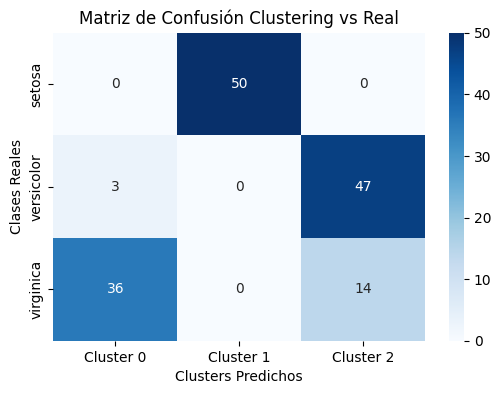

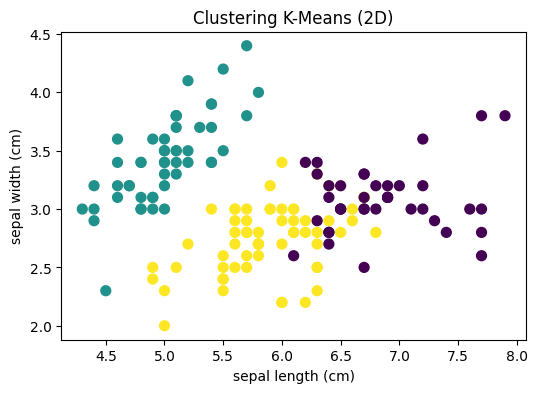

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score
import seaborn as sns


# Cargar dataset
iris = load_iris()
X = iris.data
y_true = iris.target
feature_names = iris.feature_names
class_names = iris.target_names


# Definir modelo K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
y_pred = kmeans.labels_


# Evaluación del clustering

# Ajuste de labels para comparar con las clases reales
# Ajuste opcional: Rándom para ver similitud
ari = adjusted_rand_score(y_true, y_pred)
print("Adjusted Rand Index:", ari)

# Matriz de confusión (visualización)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Cluster {i}" for i in range(3)],
            yticklabels=class_names)
plt.xlabel("Clusters Predichos")
plt.ylabel("Clases Reales")
plt.title("Matriz de Confusión Clustering vs Real")
plt.show()


plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='viridis', s=50)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Clustering K-Means (2D)")
plt.show()

# TFG 2- Deep Learning

🎯 **Objetivo.** Aplicar técnicas de:

✅ Aprendizaje Supervisado: CNN

✅ Aprendizaje No Supervisado: IA Generativa simple

## 🔎 Parte A — Supervisado (clasificación)

Modelo: CNN

Dataset: MNIST

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Cargar MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizar a [0,1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Añadir dimensión de canal (necesario para Conv2D)
X_train = X_train[..., np.newaxis]  # shape (60000,28,28,1)
X_test = X_test[..., np.newaxis]    # shape (10000,28,28,1)

# Definir modelo CNN
inputs = tf.keras.Input(shape=(28,28,1))
x = layers.Conv2D(16, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

cnn_model = models.Model(inputs=inputs, outputs=outputs)
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar CNN
history = cnn_model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# Evaluar CNN
test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
print("\nCNN - Test accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9115 - loss: 0.3108 - val_accuracy: 0.9632 - val_loss: 0.1308
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9680 - loss: 0.1080 - val_accuracy: 0.9728 - val_loss: 0.0935
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9774 - loss: 0.0769 - val_accuracy: 0.9760 - val_loss: 0.0791
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9770 - loss: 0.0724

CNN - Test accuracy: 0.9769999980926514


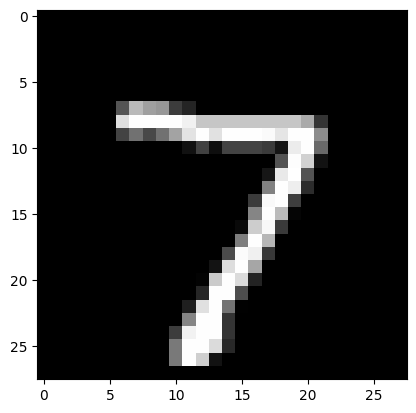

Predicción: 7, Etiqueta real: 7


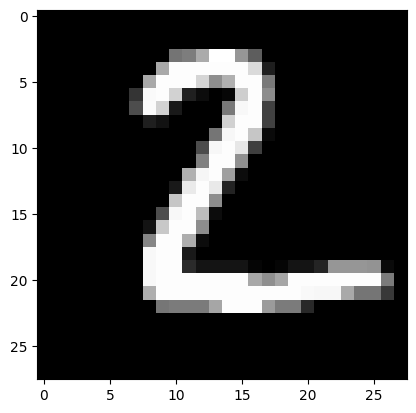

Predicción: 2, Etiqueta real: 2


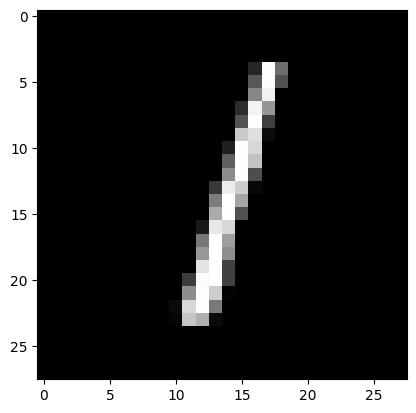

Predicción: 1, Etiqueta real: 1


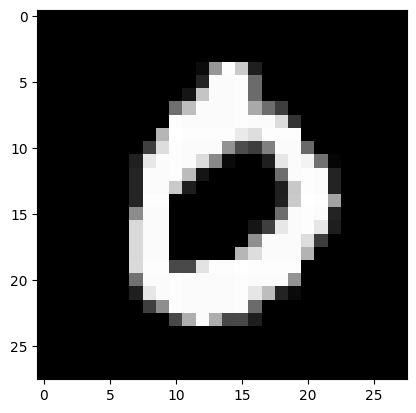

Predicción: 0, Etiqueta real: 0


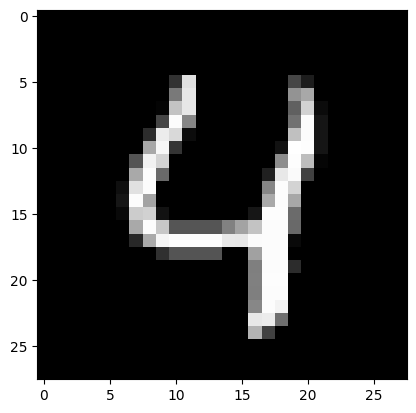

Predicción: 4, Etiqueta real: 4


In [4]:
for i in range(5):
    img = X_test[i]
    plt.imshow(img.squeeze(), cmap='gray')
    plt.show()

    img_input = img[np.newaxis, ...]  # forma (1,28,28,1)
    pred = np.argmax(cnn_model.predict(img_input, verbose=0))
    print(f"Predicción: {pred}, Etiqueta real: {y_test[i]}")


## 🔎 Parte B — No supervisado (IA generativa)


Modelo: Autoencoder

Dataset: MNIST

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2269 - val_loss: 0.1463
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1303 - val_loss: 0.1165
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1120 - val_loss: 0.1056
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1044 - val_loss: 0.1002
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0999 - val_loss: 0.0968
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0970 - val_loss: 0.0946
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0951 - val_loss: 0.0932
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0940 - val_loss: 0.0923
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0929 - val_loss: 0.0914
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0920 - val_loss: 0.0904
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0911 - val_loss: 0.0896
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

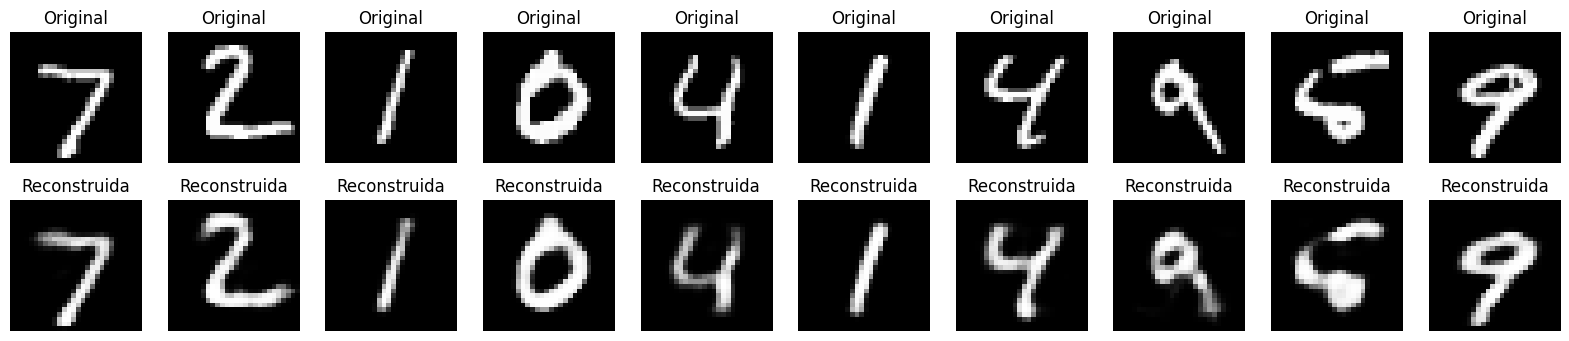

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


# Cargar MNIST
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar (784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


# Definir Autoencoder

encoding_dim = 32  # compresión fuerte

input_img = tf.keras.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento

autoencoder.fit(
    X_train,
    X_train,   # <- importante: entrada = salida
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Reconstrucción

decoded_imgs = autoencoder.predict(X_test[:10])

# Visualización

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()